# MATH/STAT-5305 Final Project - Measuring Red Wine Quality Using Statistical Models

**Carlos Cruz, Troyce Mays**

Due: December 2nd, 2024, at 11:59PM

Cutoff Date: December 9th, 11:59PM

## Introduction and Literature Review

**Introduction**     

Wine quality is often considered a subjective measurement open to interpretation and differences in the palette; however, for years wine quality has been measured with both tasting and laboratory techniques. The laboratory techniques used produce quantitative results, which allow for the regulated testing of wines for their quality and the ability to make predictive models based on the aforementioned quantitative values. This project seeks to explore the literature behind winemaking, the common quantitative variables used in testing quality, and the models currently developed for the field.

Generally, wine quality is tested either through sensory evaluations or physicochemically. Sensory evaluations are typically in-depth evaluations representing the judging of wine for quality by those with trained palettes to do so through grading color, smells, and most importantly, the taste of wine. Physicochemical methods represent quantitative chemical values obtained through laboratory testing. Both physicochemical and sensory methods are crucial to the quality control of wine, and affect all aspects of its process such as pricing, distribution, health regulations, and overall marketing of the wine itself. Due to sensory methods being innately subjective, as the overall palette of a judge would be specifically unique to them, appropriate models must exist to predict wine quality using the physicochemical factors of wine. In this project, wine quality determined by tasting will be the predictor variable, $Y$, and the predictor variables, $X_j$‘s, will be the chemical properties used in laboratory analysis.

To build a predictive model for wine quality, we started with a dataset containing chemical properties and quality ratings. By refining the dataset and testing higher-order and interaction terms, we developed a simpler model that balances accuracy and interpretability. This project aims to evaluate the impact of these adjustments and determine whether a straightforward approach can effectively predict wine quality.

**Literature Review**

To measure the quality of wine using statistical models, a dataset of officially tested wine samples from May 2004 to February 2007 was obtained from the UCI Machine Learning Repository. This same dataset was originally used by Cortez et. al for their testing of wine quality using machine learning and data mining techniques.

**Variable Literature**

The variables used within the selected wine dataset include fixed and volatile acidity, citric acid content, residual sugar content, chloride content, free and total sulfur dioxide content, density of the wine, pH of the wine, sulfate content of the wine, alcohol concentration of the wine, and the quality rating of the wine. The quality ratings of wine are the only variable not obtained through laboratory methods, and the classification of this variable varies significantly across the literature. Some cases of quality ratings use solely categorical values, and others use dramatically different numerical scales to measure wine quality. These numerical scales can be a 5-star system, a scale of 0-8, 0-20, and even 0-100; which makes measuring the overall quality of wines an even more subjective process than it already is innately. In the selected wine dataset, the quality rating of the wine is rated on a 0 to 10 numerical scale, with 0 representing a wine that is completely inconsumable and 10 representing a completely perfect wine in the eyes of a wine taster and consumer (Cortez et al., 2009). The chemical and physicochemical variables throughout each article of literature also varied dramatically. Literature varied from using upwards of 50 features to as little as the 11 chemical features used in the selected dataset. Most datasets included the 11 chemical features in the selected dataset, though some went as far as to label more specific features such as common chemical structures that majorly contribute to the tastes of wines.

The literature also vaguely elaborates on the main chemical and physicochemical properties of wine as well. The pH of wine is a large indicator of the fermentation process and how successful aging wine can be. Sulfur dioxide (measured in free content and total contents) helps to prevent oxidation by acting as an antimicrobial agent and maintaining wine freshness (sulfate content is a measurement stemming from Sulfur dioxide). Fixed acidity of wines refers to acidic compounds that remain after the boiling steps of manufacturing, and volatile acidity refers to the acidic compounds that readily evaporate during this process. Citric acid content often stems from the acidity measurements but affects the flavors of wine dramatically. Alcohol content and density are simply their appropriate measurements in the day-to-day world. Residual sugar is not a property unique to wine, and it is a measurement of sugars left over after fermentation has concluded. The chloride content in wine can vary dramatically from wine to wine, as it is measuring the chloride contents from the grapes used in manufacturing which get their chloride content from the soils and conditions they grew in.

**Literature Methods**

All sources of applicable literature used machine learning algorithms in addition to other computational methods to create advanced statistical models for varying datasets. Modeling methods in observed literature included Multiple Linear Regression, Data Mining, Neural Networks, and the generation of assistive synthetic data using the Synthetic Minority over Sampling Technique (SMOTE), and general Machine Learning (ML) techniques. Some specific ML techniques used throughout the literature included Support Vector Machines, Random Forests, K-nearest neighbors, Gaussian Naive Bayes, and more to classify the best possible features for models and obtain accurate model results.

**Literature Results**

The results of the varying applicable literature generally produce models with accuracies ranging from as low as around 30-40%, to as high as around 80-90% accuracy depending on the methods used. Most applicable literature included machine learning in their algorithms, which helped contribute to the accurate 80-90% ranges achieved in some literature. Generally, the varying literature stresses the importance of having some form of statistical models to coincide with the enology experts who study wine regularly. Having these accurate statistical models can help generally classify wines, train future wine experts in their sensory testing, and provide quality control to what could be classified as a subjective grading system in a popular industry.


## Methods

### **Importing Packages and Libraries**

We install and load the **readxl** package to work with Excel files in R. This lets us import our dataset into R.


In [ ]:
## Importing package and library to read excel files
install.packages("readxl")
library(readxl)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Before the data was imported, a small amount of feature engineering was conducted in Microsoft Excel. The csv file from the *UCI Machine Learning Repository* was obtained. This csv file contained all data of interest separated by semicolons within a single column, so the built in "Text to Columns" feature was used in Microsoft Excel to get an easier to work with dataset. The resulting data was saved as an Excel Workbook under the name "`winequality-red.xlsx`" for future use.

In [ ]:
## Import Red Wine Data (upload to Colab runtime first)
RedWineData <- read_excel("winequality-red.xlsx")

# Get dimensions of the data
rows = nrow(RedWineData)
cols = ncol(RedWineData)

# Checking dimensions
cat(paste0("The dimensions of the data are: ", rows,
   " rows and ", cols, " columns\n\n"))

# Viewing data
head(RedWineData)

The dimensions of the data are: 1599 rows and 12 columns



fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5
7.8,0.88,0.00,2.6,0.098,25,67,0.9968,3.20,0.68,9.8,5
7.8,0.76,0.04,2.3,0.092,15,54,0.9970,3.26,0.65,9.8,5
11.2,0.28,0.56,1.9,0.075,17,60,0.9980,3.16,0.58,9.8,6
7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5
7.4,0.66,0.00,1.8,0.075,13,40,0.9978,3.51,0.56,9.4,5


### **Restructuring Data as a Data Frame**

We turn the imported dataset into a **data frame** so we can work with it more easily.


In [ ]:
redwine = data.frame(RedWineData)

### **Defining Variables**

We set **Y** as the target variable (wine quality) and **X1 to X11** as the predictors, which are different chemical properties of the wine. These variables will be used to build the model.


In [ ]:
Y = redwine[,12] # Output: Wine Quality

X1 = redwine[,1] # Fixed Acidity
X2 = redwine[,2] # Volatile Acidity
X3 = redwine[,3] # Citric Acid
X4 = redwine[,4] # Residual Sugar
X5 = redwine[,5] # Chlorides
X6 = redwine[,6] # Free Sulfur Dioxide
X7 = redwine[,7] # Total Sulfur Dioxide
X8 = redwine[,8] # Density
X9 = redwine[,9] # pH
X10 = redwine[,10] # Sulphates
X11 = redwine[,11] # Alcohol

### **Initial Model Fit and Summary**

We fit the first model using all the predictors to see how well they explain wine quality. The **`summary` function** gives details like which predictors are important and how well the model works.

In [ ]:
rwine_model = lm(Y~X1+X2+X3+X4+X5+X6+X7+X8+X9+X10+X11)
summary(rwine_model)


Call:
lm(formula = Y ~ X1 + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 + 
    X10 + X11)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.68911 -0.36652 -0.04699  0.45202  2.02498 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.197e+01  2.119e+01   1.036   0.3002    
X1           2.499e-02  2.595e-02   0.963   0.3357    
X2          -1.084e+00  1.211e-01  -8.948  < 2e-16 ***
X3          -1.826e-01  1.472e-01  -1.240   0.2150    
X4           1.633e-02  1.500e-02   1.089   0.2765    
X5          -1.874e+00  4.193e-01  -4.470 8.37e-06 ***
X6           4.361e-03  2.171e-03   2.009   0.0447 *  
X7          -3.265e-03  7.287e-04  -4.480 8.00e-06 ***
X8          -1.788e+01  2.163e+01  -0.827   0.4086    
X9          -4.137e-01  1.916e-01  -2.159   0.0310 *  
X10          9.163e-01  1.143e-01   8.014 2.13e-15 ***
X11          2.762e-01  2.648e-02  10.429  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual stan

Note that the variables for Fixed Acidity (X1), Citric Acid (X3), Residual Sugar (X4), and Density (X8) do not have statistical significance in the above model summary. However, Volatile Acidity (X2), Chlorides (X5), Total Sulfur Dioxide (X7), Sulphates (X10), and Alcohol content (X11) all have strong statistical significance in comparison. This implies that variables X1, X3, X4, and X8 have little impact on overall model performance, and can most likely be removed.

**Defining Predicted Values and Residuals**

We calculate **Yhat** (the predicted wine quality) using the model and **e** (the residuals), which are the differences between the actual and predicted values. This helps us understand how well the model is performing.


In [ ]:
# Defining Yhat
Yhat = predict(rwine_model)
# Checking Yhat
head(Yhat)
# Defining residuals (e)
e = residuals(rwine_model)
# Checking residuals (e)
head(e)

1        2        3        4        5        6 
5.032850 5.137880 5.209895 5.693858 5.032850 5.065570

1           2           3           4           5           6 
-0.03285045 -0.13787975 -0.20989474  0.30614206 -0.03285045 -0.06557035

**Plotting Actual vs. Predicted Values**

We make a plot of the actual wine quality (**Y**) against the predicted wine quality (**Yhat**) to visually check how well the model’s predictions match the real data.

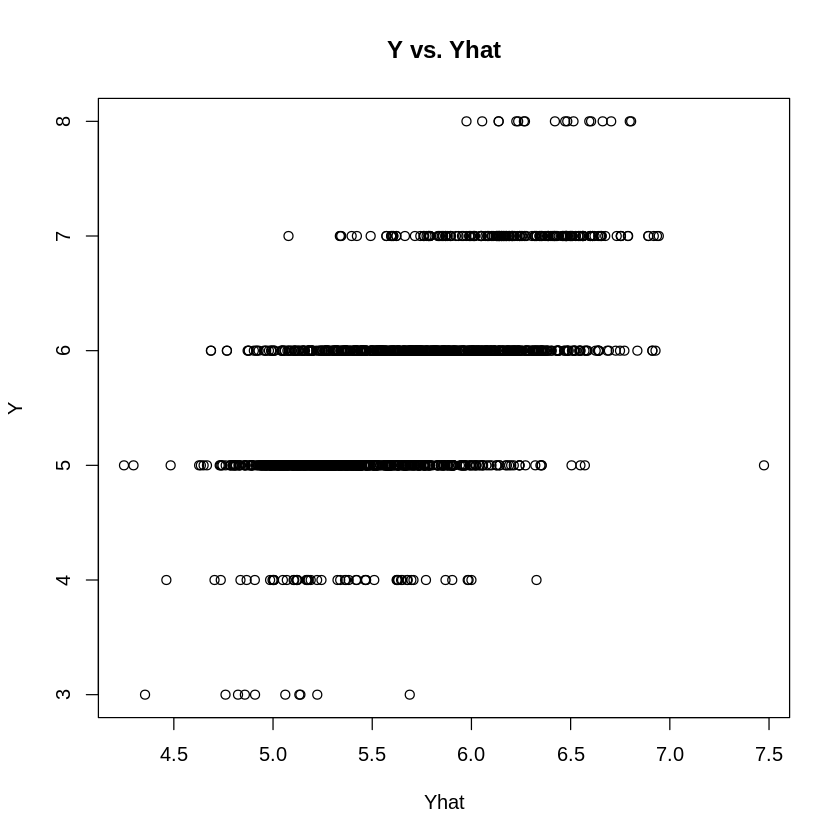

In [ ]:
plot(Yhat,Y,
  main = "Y vs. Yhat")

### **Diagnostics**

#### Original Model


	Shapiro-Wilk normality test

data:  e
W = 0.99087, p-value = 1.954e-08


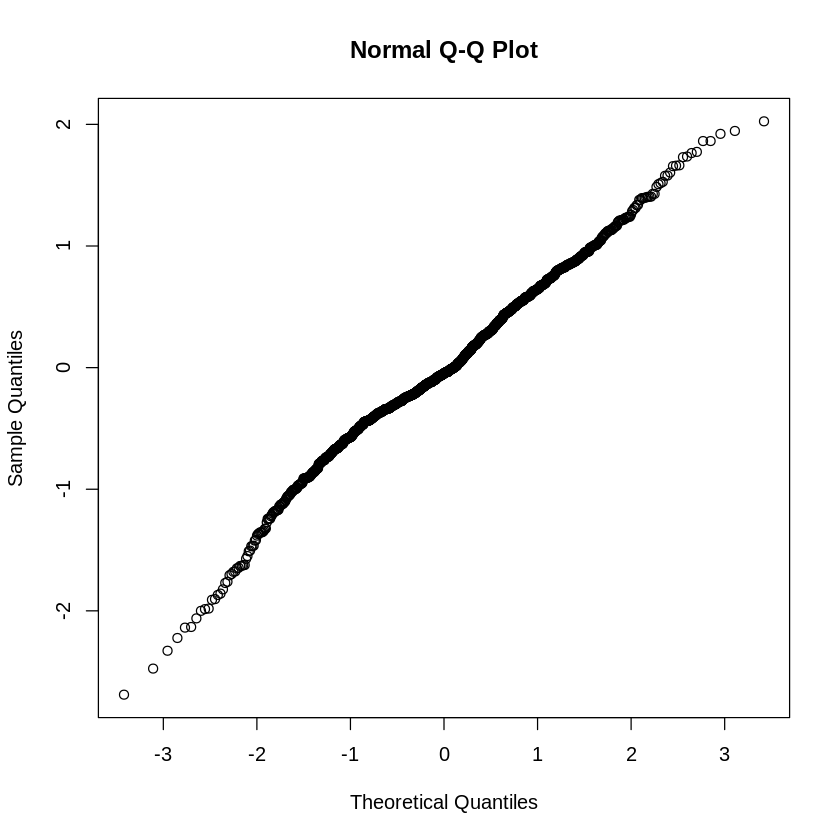

In [ ]:
## Checking for normality of error terms with a QQ plot
# Conducting a shapiro wilks test
shapiro.test(e)
# Plotting a Normal QQ PLot
qqnorm(e)

There appears to be slight curvature in the Normal Q-Q Plot, and the p-value for the Shapiro-Wilks normality test is small. This provides statistical evidence that the error terms are not normally distributed in the model.

In [ ]:
## Checking for constancy of error variance assumption
# Define and Conduct a Brown-Forsythe test

########################################################################
#Brown Forsythe Test
#
#e is a vector of residuals, and x is some vector

brown.forsythe=function(e,x){
  m=median(x)
  e1=e[x<=m]
  e2=e[x>m]
  e1med=median(e1)
  e2med=median(e2)
  d1=abs(e1-e1med)
  d2=abs(e2-e2med)
  d1bar=mean(d1)
  d2bar=mean(d2)
  n1=length(e1)
  n2=length(e2)
  sp=sqrt((sum((d1-d1bar)^2)+sum((d2-d2bar)^2))/(n1+n2-2))
  t=(d1bar-d2bar)/(sp*sqrt(1/n1+1/n2))
  return(2*pt(abs(t),n1+n2-2,lower.tail=FALSE))
}
#########################################################################

# Conducting the test
brown.forsythe(e, Yhat)

[1] 9.191749e-09

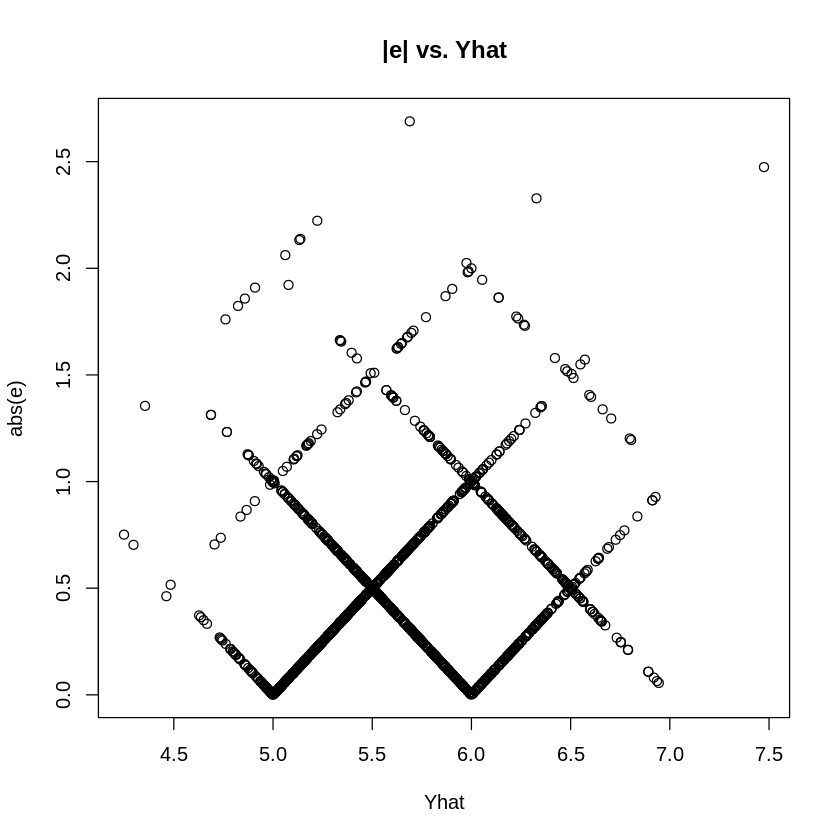

In [ ]:
## Checking for constancy of error variance assumption
# Plot of |e| vs Yhat
plot(Yhat, abs(e),
  main="|e| vs. Yhat")

Although there is no real observable pattern appearing in the above $|e|$ vs. $\hat{Y}$ plot, there is a small p-value for the Brown-Forsythe test. Therefore, it can be concluded that the above model as is not satisfy the assumption of homoscedastic error terms. A transformation of the model would be necessary for it to be succesful and satisfy appropriate model assumptions.

In [ ]:
# Diagnostics: Extract R-squared and Adjusted R-squared
r_squared = summary(rwine_model)$r.squared
adjusted_r_squared = summary(rwine_model)$adj.r.squared

# Print the results
cat("R-squared:", r_squared, "\n")
cat("Adjusted R-squared:", adjusted_r_squared, "\n")

R-squared: 0.3605517 
Adjusted R-squared: 0.3561195 


In [ ]:
# Predict wine quality using the model
predicted_Y = predict(rwine_model, newdata = redwine)

# Display the first few predictions
head(predicted_Y)

# Comparing predictions with actual values
comparison = data.frame(Actual = redwine$quality, Predicted = predicted_Y)
head(comparison)

1        2        3        4        5        6 
5.032850 5.137880 5.209895 5.693858 5.032850 5.065570

,Actual,Predicted
,<dbl>,<dbl>
1,5,5.032850
2,5,5.137880
3,5,5.209895
4,6,5.693858
5,5,5.032850
6,5,5.065570


In [ ]:
# Calculate Mean Squared Error
mse <- mean((redwine$quality - predicted_Y)^2)
cat("Mean Squared Error:", mse, "\n")

Mean Squared Error: 0.4167672 


In [ ]:
# Calculate Root Mean Squared Error
rmse = sqrt(mse)
cat("Root Mean Squared Error:", rmse, "\n")

Root Mean Squared Error: 0.6455751 


In [ ]:
rwine_model


Call:
lm(formula = Y ~ X1 + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 + 
    X10 + X11)

Coefficients:
(Intercept)           X1           X2           X3           X4           X5  
  21.965208     0.024991    -1.083590    -0.182564     0.016331    -1.874225  
         X6           X7           X8           X9          X10          X11  
   0.004361    -0.003265   -17.881164    -0.413653     0.916334     0.276198  


First model equation:

$Y = 22.0 + 0.0250X_1 - 1.08X_2-0.183X_3+0.0163X_4-1.87X_5+0.00436X_6-0.00327X_7-17.9X_8-0.414X_9+0.916X_{10}+0.276X_{11}$

This first model was built to predict wine quality using chemical properties. Predictors like volatile acidity, chlorides, free sulfur dioxide, total sulfur dioxide, pH, sulphates, and alcohol had the strongest relationships with wine quality based on their p-values, which show a stronger statistical relationship with wine quality. The model explains about 36% of the differences in wine quality based on the chemical properties (R^2 = 0.3606). It has a Mean Squared Error (MSE) of 0.4167 and a Root Mean Squared Error (RMSE) of about 0.65, meaning the predictions are off by about 0.65 units of wine quality on average. Overall, the original model does a decent job at predicting wine quality, especially since wine quality is subjective.


#### Second Model
Creating a second model with only the statistically significant variables (Volatile Acidity (X2), Chlorides (X5), Total Sulfur Dioxide (X7), Sulphates (X10), and Alcohol content (X11)) may have better results. X6 (Free Sulfur Dioxide) and X9 (pH) have slight statistical significance and may be included.

In [ ]:
## Performing Step-Wise Variable Selection
steprwine1 = step(rwine_model)

Start:  AIC=-1375.49
Y ~ X1 + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 + X10 + X11

       Df Sum of Sq    RSS     AIC
- X8    1     0.287 666.70 -1376.8
- X1    1     0.389 666.80 -1376.5
- X4    1     0.498 666.91 -1376.3
- X3    1     0.646 667.06 -1375.9
<none>              666.41 -1375.5
- X6    1     1.694 668.10 -1373.4
- X9    1     1.957 668.37 -1372.8
- X5    1     8.391 674.80 -1357.5
- X7    1     8.427 674.84 -1357.4
- X10   1    26.971 693.38 -1314.0
- X2    1    33.620 700.03 -1298.8
- X11   1    45.672 712.08 -1271.5

Step:  AIC=-1376.8
Y ~ X1 + X2 + X3 + X4 + X5 + X6 + X7 + X9 + X10 + X11

       Df Sum of Sq    RSS     AIC
- X1    1     0.108 666.81 -1378.5
- X4    1     0.231 666.93 -1378.2
- X3    1     0.654 667.35 -1377.2
<none>              666.70 -1376.8
- X6    1     1.829 668.53 -1374.4
- X9    1     4.325 671.02 -1368.5
- X7    1     8.728 675.43 -1358.0
- X5    1     8.761 675.46 -1357.9
- X10   1    27.287 693.98 -1314.7
- X2    1    35.000 701.70 -1297.0
- X1

In [ ]:
# Checking step-wise model summary
summary(steprwine1)


Call:
lm(formula = Y ~ X2 + X5 + X6 + X7 + X9 + X10 + X11)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.68918 -0.36757 -0.04653  0.46081  2.02954 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.4300987  0.4029168  10.995  < 2e-16 ***
X2          -1.0127527  0.1008429 -10.043  < 2e-16 ***
X5          -2.0178138  0.3975417  -5.076 4.31e-07 ***
X6           0.0050774  0.0021255   2.389    0.017 *  
X7          -0.0034822  0.0006868  -5.070 4.43e-07 ***
X9          -0.4826614  0.1175581  -4.106 4.23e-05 ***
X10          0.8826651  0.1099084   8.031 1.86e-15 ***
X11          0.2893028  0.0167958  17.225  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6477 on 1591 degrees of freedom
Multiple R-squared:  0.3595,	Adjusted R-squared:  0.3567 
F-statistic: 127.6 on 7 and 1591 DF,  p-value: < 2.2e-16


The results from step-wise model selection resulted in a model that only selected the minor and major statistically significant variables from the original `rwine_model`. From here diagnostics should be ran on this new model.

In [ ]:
## Defining and checking new model based on model building
rwinemodel2 = lm(Y~X2+X5+X6+X7+X9+X10+X11)
summary(rwinemodel2)


Call:
lm(formula = Y ~ X2 + X5 + X6 + X7 + X9 + X10 + X11)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.68918 -0.36757 -0.04653  0.46081  2.02954 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.4300987  0.4029168  10.995  < 2e-16 ***
X2          -1.0127527  0.1008429 -10.043  < 2e-16 ***
X5          -2.0178138  0.3975417  -5.076 4.31e-07 ***
X6           0.0050774  0.0021255   2.389    0.017 *  
X7          -0.0034822  0.0006868  -5.070 4.43e-07 ***
X9          -0.4826614  0.1175581  -4.106 4.23e-05 ***
X10          0.8826651  0.1099084   8.031 1.86e-15 ***
X11          0.2893028  0.0167958  17.225  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6477 on 1591 degrees of freedom
Multiple R-squared:  0.3595,	Adjusted R-squared:  0.3567 
F-statistic: 127.6 on 7 and 1591 DF,  p-value: < 2.2e-16


In [ ]:
## Defining new Yhat and residuals (e)
# Defining Yhat
Yhat = predict(rwinemodel2)
# Defining residuals (e)
e = residuals(rwinemodel2)

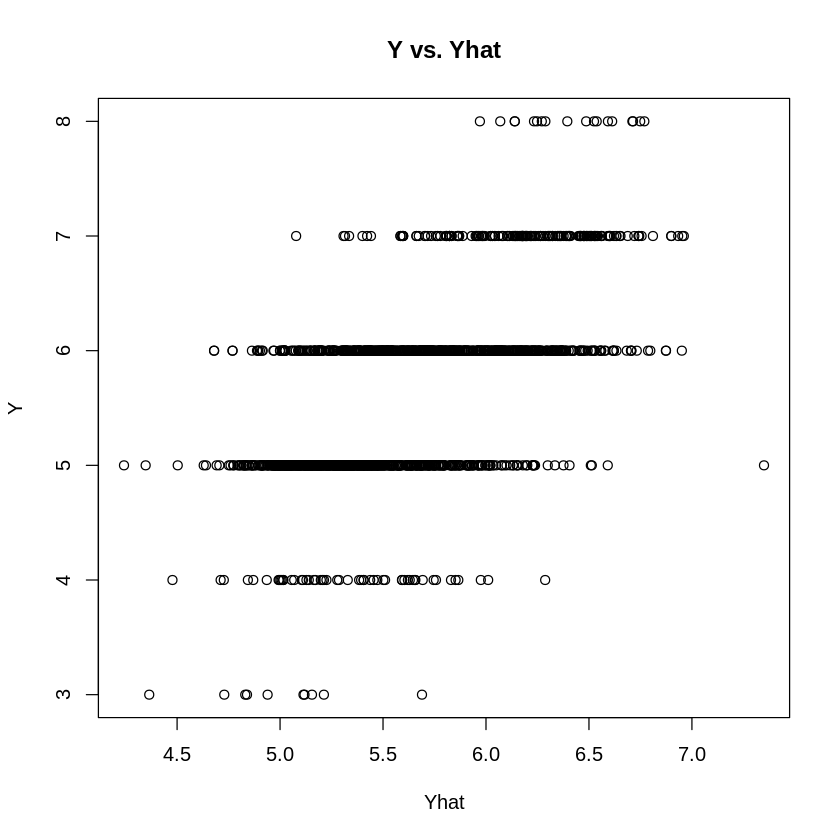

In [ ]:
## Checking a plot of Y vs. Yhat
plot(Yhat,Y,
  main = "Y vs. Yhat")


	Shapiro-Wilk normality test

data:  e
W = 0.99137, p-value = 4.321e-08


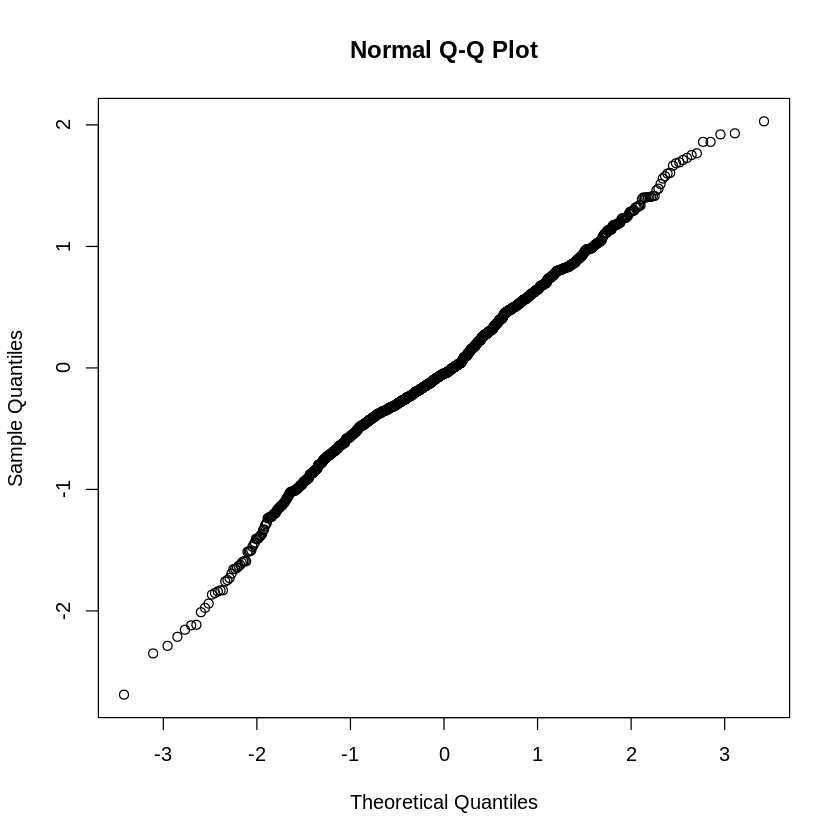

In [ ]:
## Checking for normality of error terms with a Q-Q plot
# Conducting a shapiro wilks test
shapiro.test(e)
# Plotting a Normal QQ PLot
qqnorm(e)

[1] 1.453438e-09

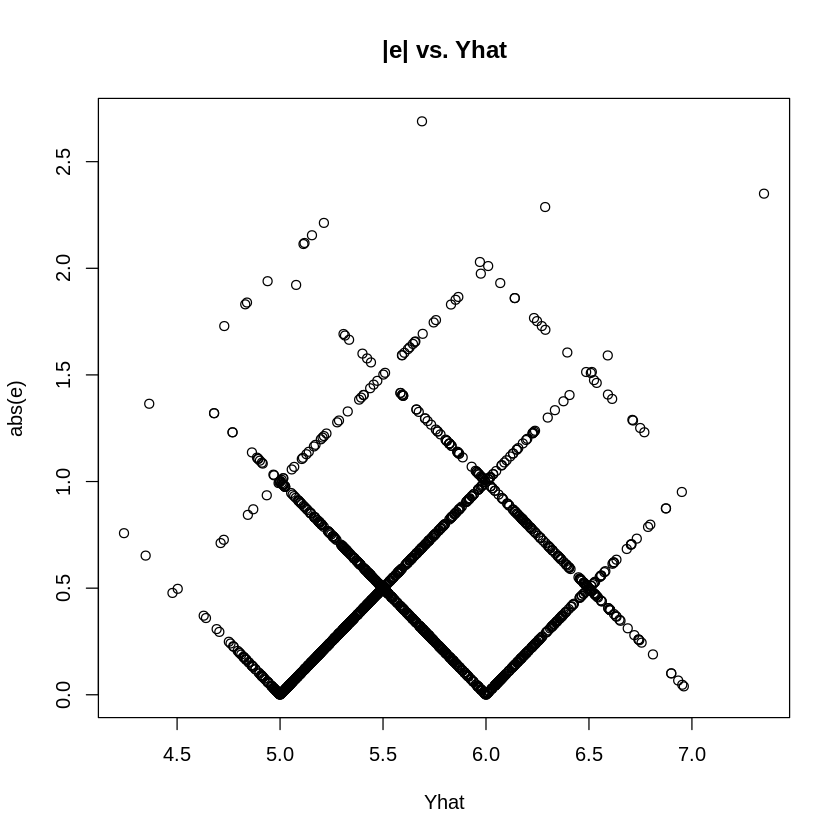

In [ ]:
## Checking for constancy of error variance assumption
# Conducting Brown-Forsythe test
brown.forsythe(e, Yhat)

# Plot of |e| vs Yhat
plot(Yhat, abs(e),
  main="|e| vs. Yhat")

In [ ]:
## Comparing the two models

# Set up an F-test to compare models
#################################################################
f.test=function(model0,model){
e02=sum((model0$residuals)^2) #Residual sum of squares for small model.
e2=sum((model$residuals)^2) #Residual sum of squares for big model.
df0=model0$df.residual #Residual degrees of freedom for small model.
df=model$df.residual #Residual degrees of freedom for big model.
f.stat=((e02-e2)/(df0-df))/(e2/df)
p.value=pf(f.stat,
df1=df0-df,
df2=df,
lower.tail=FALSE)
return(list(f.stat=f.stat,p.value=p.value))
}
########################################################################

# Conduct F-test
f.test(rwinemodel2, rwine_model)

$f.stat
[1] 0.6705817

$p.value
[1] 0.6124118

The large p-value of the F-test shows that we fail to reject the second model (`rwinemodel2`) as our null hypothesis, so this secondary model will become the new main model for predicting wine quality. It has comparable performance metrics as well, with almost identical $R^2$ and adjusted $R^2$ values, and with less variables which are all statistically significant. Before finalizing the second model, a Box-Cox transformation will be applied to help fulfill residual model assumptions.

### **Remedial Measures**

**Performing a Box-Cox Transformation**

In this section, we will attempt use a Box-Cox Transformation to fix problems with the model’s residuals, like non-normality or unequal variance. The transformation finds the an optimized lambda value, which tells us how to adjust the data.


In [ ]:
## Set up and perform a Box-Cox Transformation on the second model

# Defining Box Cox transformation function
###################################################################################
#Box Cox Transformation
#
#Y is the dependent variable from a regression equation, and
#X is the design matrix.
#lambdarange is a vector containing the possible values of lambda
box.cox=function(Y,X,lambdarange){
n=length(Y)
K2=(prod(Y^(1/n)))
L=length(lambdarange)
SSE=1:L
for(l in 1:L){
lambda=lambdarange[l]
K1=1/(lambda*K2^(lambda-1))
if(lambda==0){W=K2*log(Y)}
if(lambda!=0){W=K1*(Y^lambda-1)}
tempmodel=lm(W~X)
SSE[l]=deviance(tempmodel)
}
i=(sort(SSE,index.return=TRUE)$ix)[1]
return(lambdarange[i])
}
######################################################################

## Conducting the Box-Cox transformation
# Defining X, a matrix with all desired predictor variables
X = cbind(X2,X5,X6,X7,X9,X10,X11)

# test 1
box.cox(Y, X, (-30:30)/10)
# test 2
box.cox(Y,X,(80:100)/100)
# test 3
box.cox(Y,X,(900:920)/1000)

[1] 0.9

[1] 0.91

[1] 0.913

The Box-Cox transformation returned $\lambda$=0.913, which can be used to transform Y and test a transformed model against the original model.

In [ ]:
## Defining lambda and transforming Y
# Defining lambda
lambda = 0.913

# Defining tY
tY = Y^lambda

In [ ]:
## Fitting the transformed model
trwinemodel2 = lm(tY~X2+X5+X6+X7+X9+X10+X11)

# Defining new Yhat
tYhat = predict(trwinemodel2)

# Defining transformed residuals (te)
te = residuals(trwinemodel2)

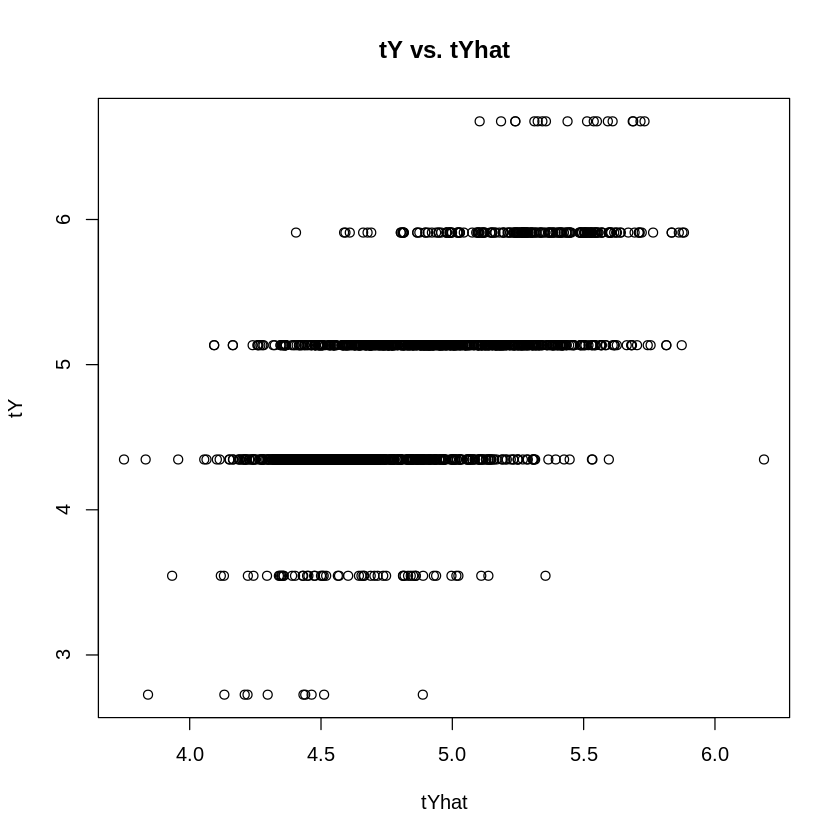

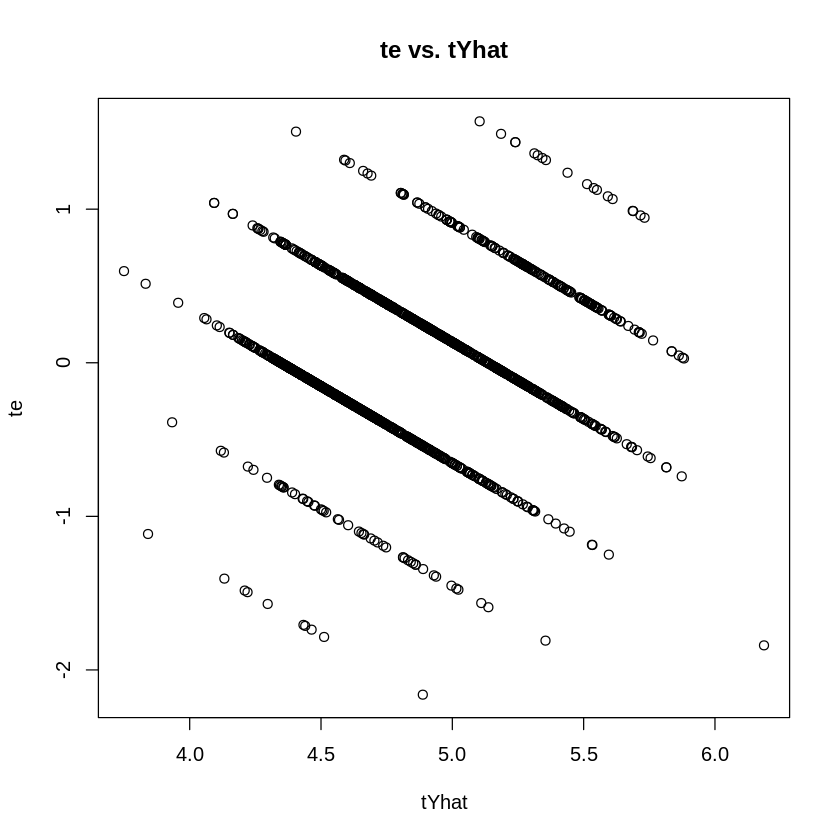

In [ ]:
## Plotting plots for observing the model
# tY vs. tYhat plot
plot(tYhat, tY,
  main = "tY vs. tYhat")

# te vs. tYhat plot
plot(tYhat, te,
  main = "te vs. tYhat")


	Shapiro-Wilk normality test

data:  te
W = 0.99041, p-value = 9.536e-09


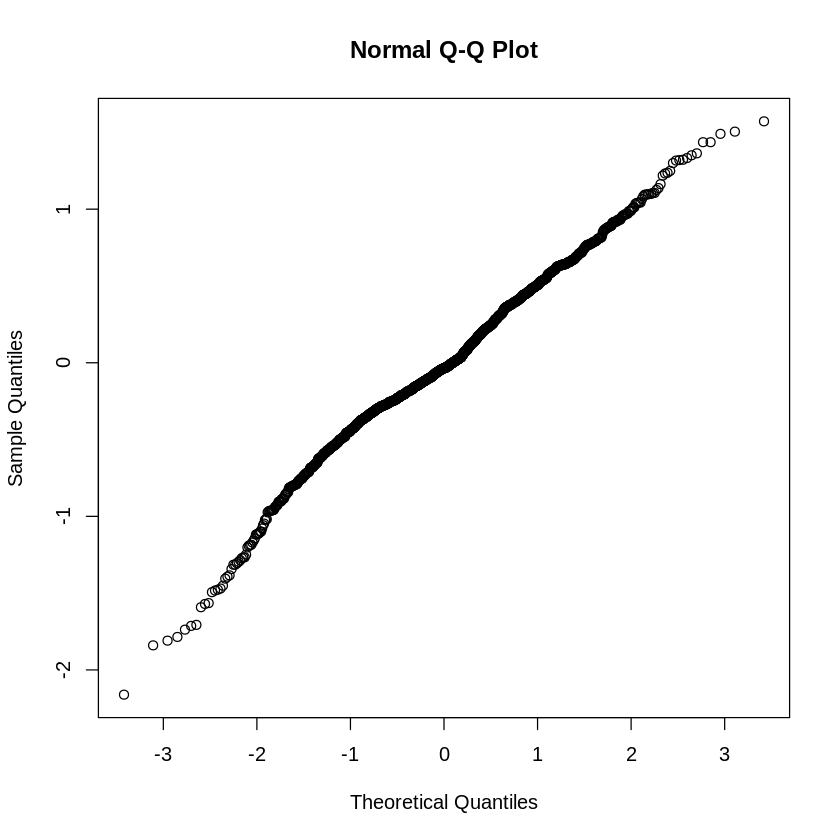

In [ ]:
## Checking the normality of residuals for the transformed model
shapiro.test(te)
qqnorm(te)

[1] 7.483886e-09

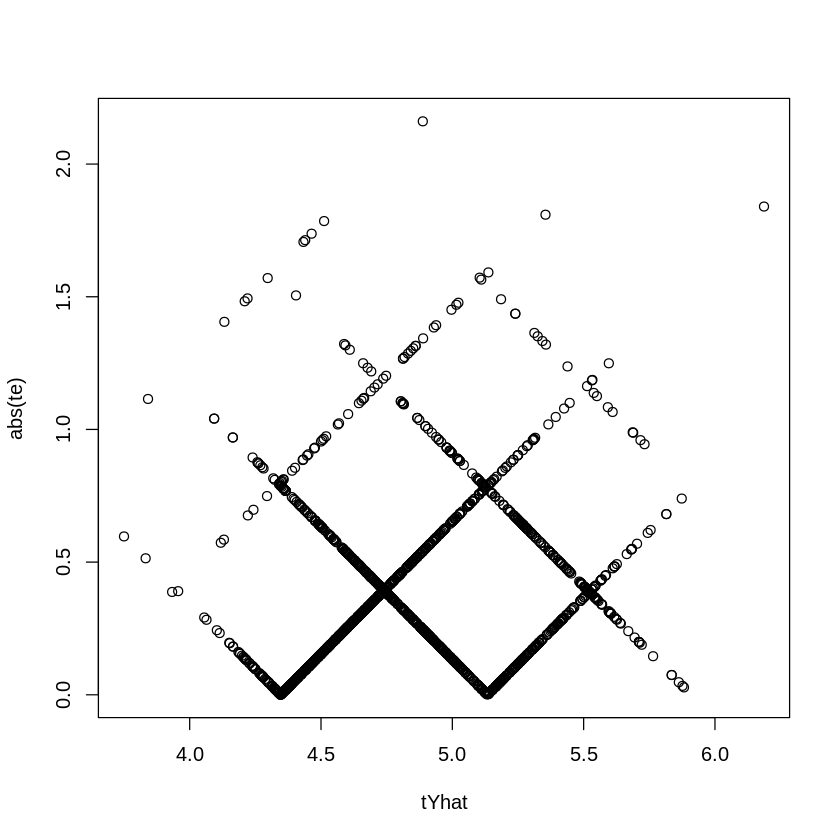

In [ ]:
## Checking for constant variance of error terms for the transformed model
brown.forsythe(te,tYhat)
plot(tYhat,abs(te))

Even after transformations, the second model still fails the assumptions of normally distributed residuals and constancy of error variance. The Shapiro-Wilk and Brown-Forsythe test both returned small p-values, even smaller than the model had originally.

In [ ]:
### Compare performance metrics of transformed model and actual values
## Applying model transformation to Y
newYhat = tYhat^(1/lambda)
newe = Y-newYhat

## Compare Results
# SSE
cat("Original SSE:", sum(e^2), "\n")
cat("New SSE:", sum(newe^2), "\n") #Smaller SSE is better

# normalized SSE
cat("Original normSSE:", var(e)/var(Y), "\n")
cat("New normSSE:", var(newe)/var(Y), "\n")   #Smaller normalized SSE is better

# R^2
cat("Original R^2:", 1-var(e)/var(Y), "\n")
cat("New R^2:", 1-var(newe)/var(Y), "\n")   #Bigger R^2 is better

Original SSE: 667.5371 
New SSE: 667.3895 
Original normSSE: 0.6405291 
New normSSE: 0.6403713 
Original R^2: 0.3594709 
New R^2: 0.3596287 


Comparing adequacy of the original `rwinemodel2` to its transformed version after a Box-Cox transformation shows that the transformation had little effect. The transformed model still failed testing for both normality of residuals and constancy of error variance, and improved very little in terms of performance. This evidence suggests that the transformation is overall unnecessary, and further diagnostics will be done on the second model, `rwinemodel2`.

### **Further Diagnostics**

In this section, we tested for possible interaction terms and higehr order terms that could be added into our model. These may help improve the performance of `rwinemodel2`, and allow it to more accurately predict wine quality.

**Checking for Higher-Order Terms**

In this section, we add higher-order terms (squared variables) to the model. These terms help the model capture non-linear relationships between predictors and wine quality. For example, the effect of Alcohol on wine quality might not increase at a constant rate—it could have a curve.

We first need to check each variable for curvature or trends with the model residuals, then add squared terms for the variables that present any correlations.


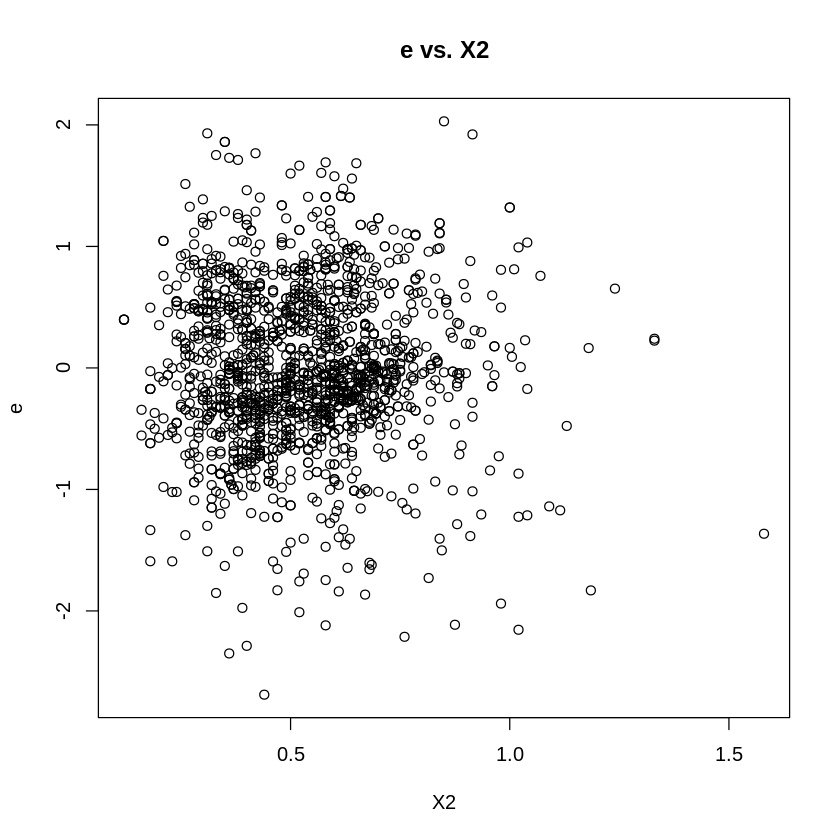

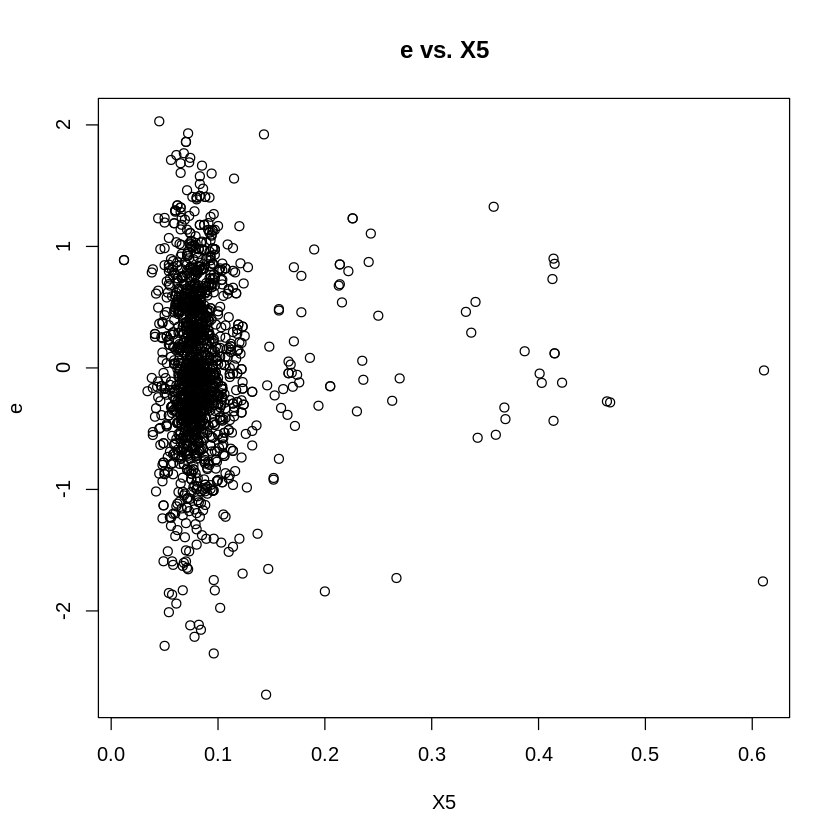

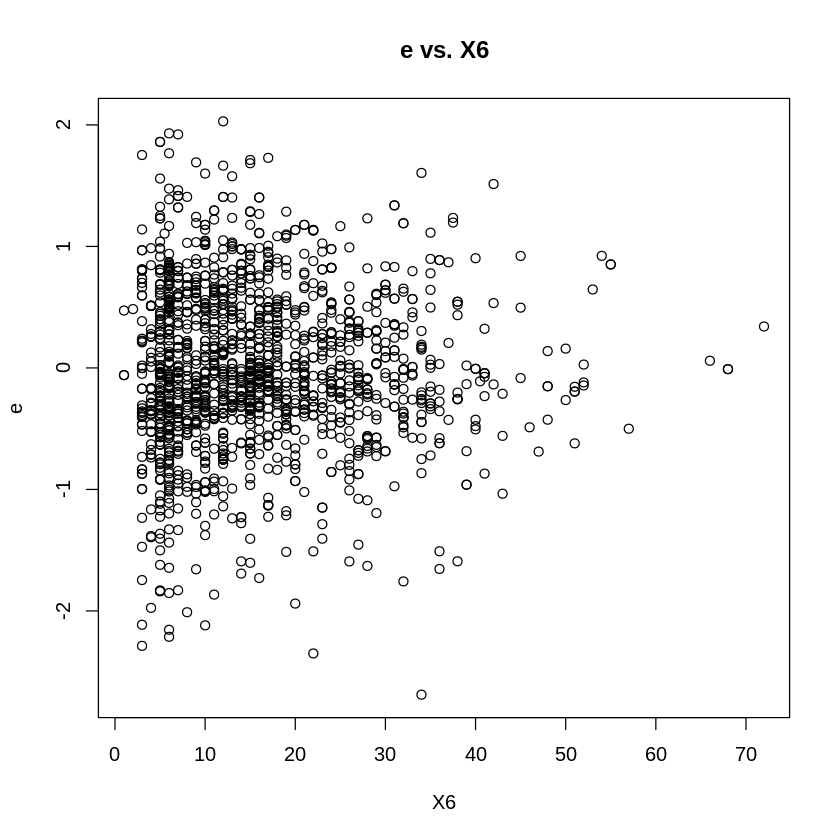

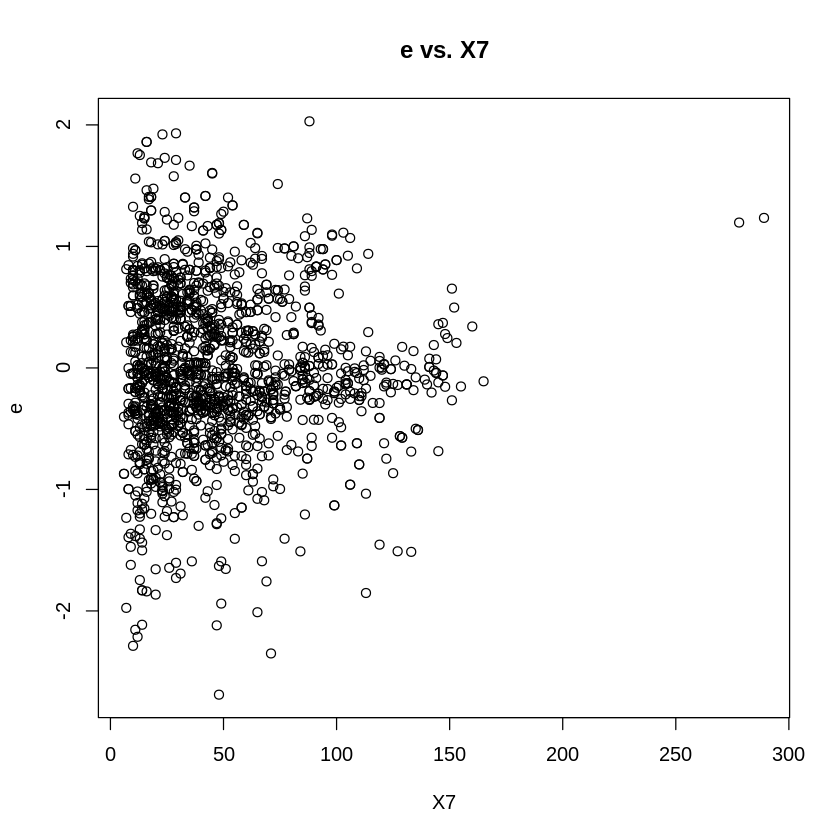

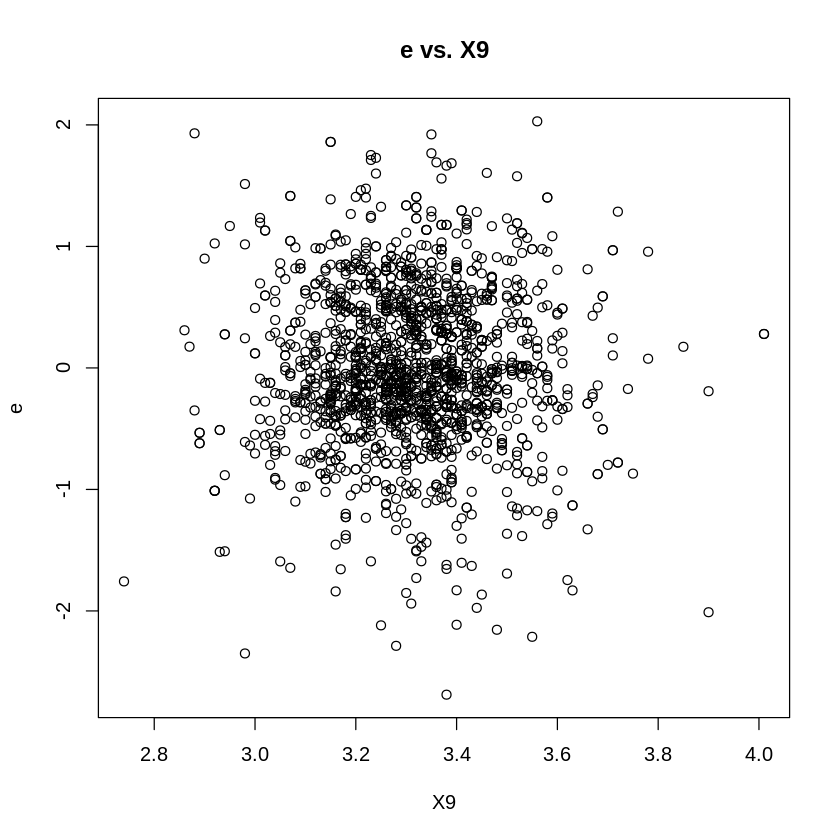

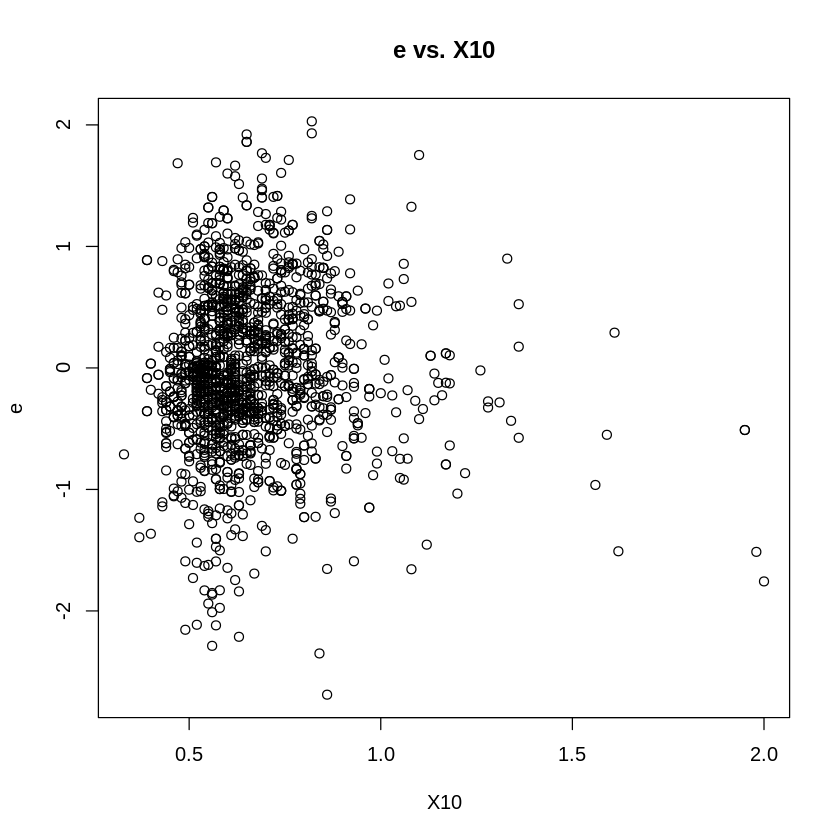

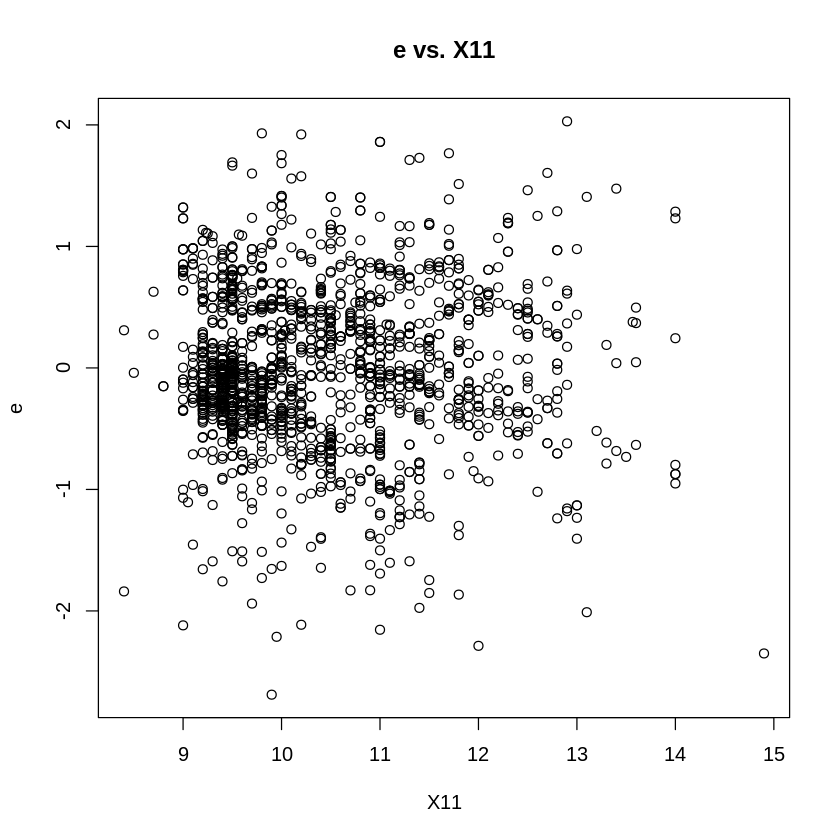

In [ ]:
## Checking plots of rwinemodel2 residuals (e) vs. variables

plot(X2, e,
  main = "e vs. X2")
plot(X5, e,
  main = "e vs. X5") # Variable of interest
plot(X6, e,
  main = "e vs. X6") # Variable of interest
plot(X7, e,
  main = "e vs. X7") # Variable of interest
plot(X9, e,
  main = "e vs. X9")
plot(X10, e,
  main = "e vs. X10")
plot(X11, e,
  main = "e vs. X11")

Variables X5, X6, and X7 all have plots that are not entirely white noise. Therefore, they are worth investigating for higher order terms.  

In [ ]:
## Fitting new model with higher order X5
# FItting the new model
rwinemodel_ho5 = lm(Y~X2+X5+X6+X7+X9+X10+X11+I(X5^2))

# Testing against rwinemodel2
f.test(rwinemodel2, rwinemodel_ho5)

$f.stat
[1] 1.683726

$p.value
[1] 0.1946183

The large p-value did not reject the null hypothesis model, `rwinemodel2`, so it can be assumed the higher order term is unnecessary.

In [ ]:
## Fitting new model with higher order X6
# FItting the new model
rwinemodel_ho6 = lm(Y~X2+X5+X6+X7+X9+X10+X11+I(X6^2))

# Testing against rwinemodel2
f.test(rwinemodel2, rwinemodel_ho6)

$f.stat
[1] 0.9675853

$p.value
[1] 0.3254328

The large p-value did not reject the null hypothesis model, `rwinemodel2`, so it can be assumed the higher order term is unnecessary.

In [ ]:
## Fitting new model with higher order X7
# FItting the new model
rwinemodel_ho7 = lm(Y~X2+X5+X6+X7+X9+X10+X11+I(X7^2))

# Testing against rwinemodel2
f.test(rwinemodel2, rwinemodel_ho7)

$f.stat
[1] 1.073438

$p.value
[1] 0.3003277

The large p-value did not reject the null hypothesis model, `rwinemodel2`, so it can be assumed the higher order term is unnecessary.

After conducting both visual and numerical testing for higher order terms, it can be concluded that no higher order terms would improve `rwinemodel2`'s performance. Each variable either had a residual plot of white noise, or had a large p-value when put through an F-test against our current secondary model.

**Checking for Interaction Terms**

Here, we add **interaction terms** to the dataset. Interaction terms help us figure out if the effect of one variable changes depending on the value of another variable. For example, two variables together might have a stronger or weaker impact on wine quality than each does on its own.

Possible interaction terms of interest are Free and Total Sulfur Dioxide as well as Volatile Acidity and pH. These pairs of terms are closely correlated within the winemaking process and their measurements.


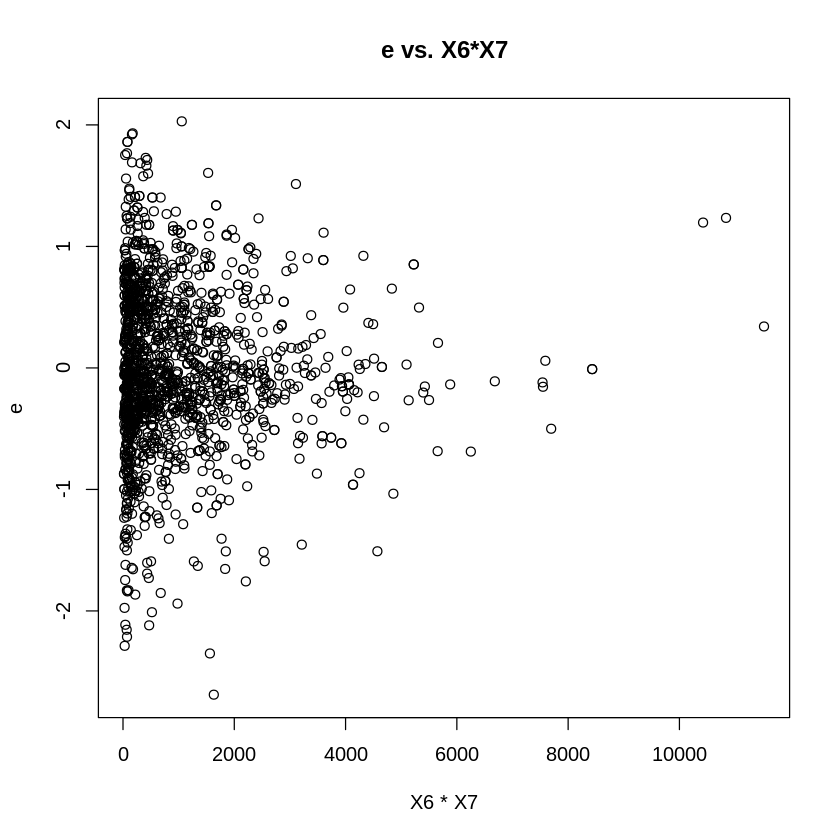

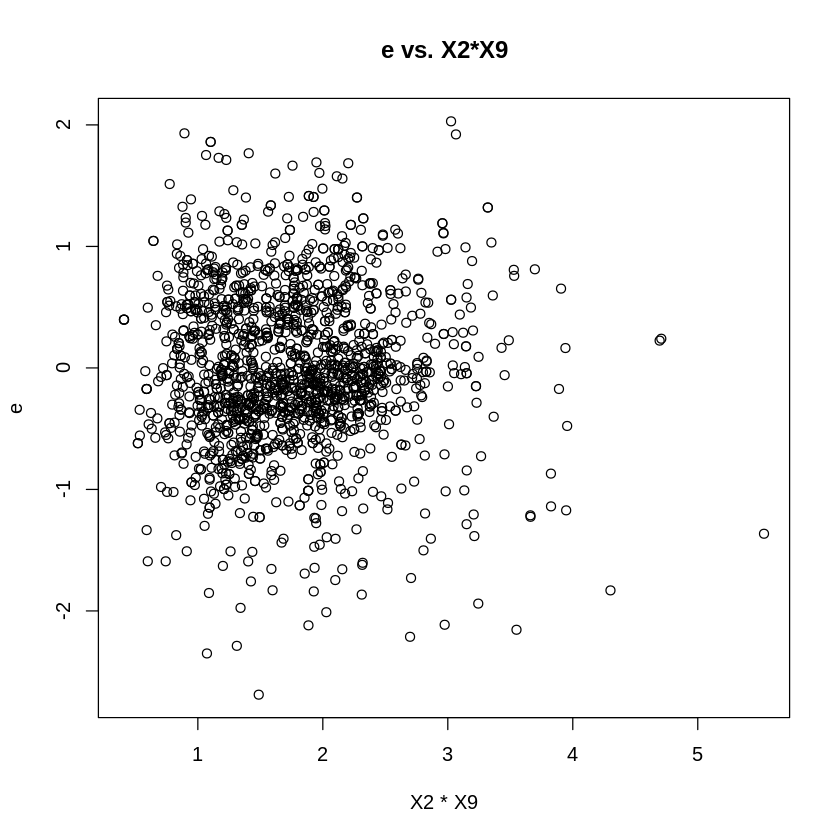

In [ ]:
## Checking plots of rwinemodel2 residuals (e) vs. interaction terms
plot(X6*X7, e,
  main = "e vs. X6*X7")
plot(X2*X9, e,
  main = "e vs. X2*X9")

The residual plots do not present any strong evidence for interaction terms being necessary between chemically related variables. Numerical testing can be done to prove this.

In [ ]:
## Fitting new model with interaction X6*X7
# FItting the new model
rwinemodel_int67 = lm(Y~X2+X5+X6+X7+X9+X10+X11+I(X6*X7))

# Testing against rwinemodel2
f.test(rwinemodel2, rwinemodel_int67)

$f.stat
[1] 0.6550485

$p.value
[1] 0.4184346

The large p-value did not reject the null hypothesis model, `rwinemodel2`, so it can be assumed the interaction term is unnecessary.

In [ ]:
## Fitting new model with interaction X2*X9
# FItting the new model
rwinemodel_int29 = lm(Y~X2+X5+X6+X7+X9+X10+X11+I(X2*X9))

# Testing against rwinemodel2
f.test(rwinemodel2, rwinemodel_int29)

$f.stat
[1] 0.6522316

$p.value
[1] 0.4194367

The large p-value did not reject the null hypothesis model, `rwinemodel2`, so it can be assumed the interaction term is unnecessary.

After conducting both visual and numerical testing for chemically similar interaction terms, it can be concluded that no interaction terms would improve `rwinemodel2`'s performance. Both interactions had a residual plot of white and a large p-value when put through an F-test against our current secondary model.

In [ ]:
# Model Comparison: Original vs. Final
# Original Model Metrics
r2_orig <- summary(rwine_model)$r.squared
adjusted_r2_orig <- summary(rwine_model)$adj.r.squared
mse_orig <- mean((Y - predict(rwine_model))^2)
rmse_orig <- sqrt(mse_orig)

# Final Model Metrics
r2_final <- summary(rwinemodel2)$r.squared
adjusted_r2_final <- summary(rwinemodel2)$adj.r.squared
mse_final <- mean((Y - predict(rwinemodel2))^2)
rmse_final <- sqrt(mse_final)

# Print results
cat("Original Model Metrics:\n")
cat(sprintf("R^2: %.4f, Adjusted R^2: %.4f\n", r2_orig, adjusted_r2_orig))
cat(sprintf("MSE: %.4f, RMSE: %.4f\n\n", mse_orig, rmse_orig))

cat("Final Model Metrics:\n")
cat(sprintf("R^2: %.4f, Adjusted R^2: %.4f\n", r2_final, adjusted_r2_final))
cat(sprintf("MSE: %.4f, RMSE: %.4f\n", mse_final, rmse_final))


Original Model Metrics:
R^2: 0.3606, Adjusted R^2: 0.3561
MSE: 0.4168, RMSE: 0.6456

Final Model Metrics:
R^2: 0.3595, Adjusted R^2: 0.3567
MSE: 0.4175, RMSE: 0.6461


After conducting numerical testing and comparing performance metrics between the `original model` and the `final model`, it can be concluded that the `final model` achieves similar predictive performance with fewer predictors. The `final model's` adjusted \( R^2 \) slightly improved,  indicating it might perform better on new data, while the differences in \( R^2 \), MSE, and RMSE are negligible. This suggests that the removed predictors did not significantly contribute to the model's overall performance, supporting the use of the more parsimonious `final model`.


## **Conclusion**

In [ ]:
## Declaring Final model and checking its summary
FinalModel = rwinemodel2
# Display Final Model and summary
FinalModel
summary(FinalModel)


Call:
lm(formula = Y ~ X2 + X5 + X6 + X7 + X9 + X10 + X11)

Coefficients:
(Intercept)           X2           X5           X6           X7           X9  
   4.430099    -1.012753    -2.017814     0.005077    -0.003482    -0.482661  
        X10          X11  
   0.882665     0.289303  



Call:
lm(formula = Y ~ X2 + X5 + X6 + X7 + X9 + X10 + X11)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.68918 -0.36757 -0.04653  0.46081  2.02954 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.4300987  0.4029168  10.995  < 2e-16 ***
X2          -1.0127527  0.1008429 -10.043  < 2e-16 ***
X5          -2.0178138  0.3975417  -5.076 4.31e-07 ***
X6           0.0050774  0.0021255   2.389    0.017 *  
X7          -0.0034822  0.0006868  -5.070 4.43e-07 ***
X9          -0.4826614  0.1175581  -4.106 4.23e-05 ***
X10          0.8826651  0.1099084   8.031 1.86e-15 ***
X11          0.2893028  0.0167958  17.225  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6477 on 1591 degrees of freedom
Multiple R-squared:  0.3595,	Adjusted R-squared:  0.3567 
F-statistic: 127.6 on 7 and 1591 DF,  p-value: < 2.2e-16


Final Model Equation:

$Y=4.43-1.01X_1-2.02X_5+0.00508X_6-0.00348X_7-0.483X_9+0.883X_{10}+0.289X_{11}$

This project focused on creating and improving models to predict wine quality using measurable chemical properties. We started with an `original model` that included all variables and then refined it into a `final model` by removing less important predictors. Both models were compared using metrics like R^2, adjusted R^2, MSE, and RMSE to evaluate how well they performed.

We also tested if adding higher-order terms or interaction terms would improve the model. Higher-order terms for `X5`, `X6`, and `X7` were tested, but the results showed they didn’t make the model better. Interaction terms, like combining `X6 and X7` or `X2 and X9`, were also tested, but they didn’t add value either.

Comparing the `original model` and the `final model` showed similar results, with the `final model` being simpler and slightly better in adjusted R^2. The small difference in performance means the removed predictors didn’t make a big impact, making the `final model` a better choice overall.

The results show that it’s possible to predict wine quality using straightforward models. While the accuracy isn’t perfect, the model gives useful insights into the factors that affect quality. This can help winemakers and quality control teams focus on the most important measurements.

In the end, the `final model` is simple, effective, and provides a good balance between accuracy and ease of use.

## **References**

Bhardwaj, P., Tiwari, P., Olejar, K., Parr, W., & Kulasiri, D. (2022). A machine learning application in wine quality prediction. Machine Learning With Applications, 8, 100261. https://doi.org/10.1016/j.mlwa.2022.100261

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Wine Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T.

Grainger, K., & Tattersall, H. (2016). Wine production and quality. John Wiley & Sons, Incorporated. https://ebookcentral.proquest.com/lib/tsul-ebooks/reader.action?docID=4306430&ppg=1

Menke, S. (2012). Winery Laboratory Manual: Wine and Must Analysis Standard Quality Testing Methods. Fort Collins, CO: Colorado State University.
[https://webdoc.agsci.colostate.edu/aes/wcrc/publications/winerylaboratorymanual%20rev2012.pdf](https://webdoc.agsci.colostate.edu/aes/wcrc/publications/winerylaboratorymanual%20rev2012.pdf)

Mor, N. S., Asras, T., Gal, E., Demasia, T., Tarab, E., Ezekiel, N., … Mor, O. (2022, February 1). Wine Quality and Type Prediction from Physicochemical Properties Using Neural Networks for Machine Learning: A Free Software for Winemakers and Customers. https://doi.org/10.31222/osf.io/ph4cu


## Authorship Distribution Statement

***Carlos Cruz***, responsible for:

- Analysis writing, model performance metrics, conclusion, reviewing and editing, original draft of remedial measures, general model building.

***Troyce Mays***, responsible for:

- Literature review, obtaining sources, model diagnostics, variable and dataset selection, final draft of remedial measures, general model building.